In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [3]:
import os
import glob

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

BATCH_SIZE = 128
EPOCHS = 20
LR = 1e-3
LATENT_DIM = 32

Using device: cuda


In [6]:
def download_dataset():
    import kagglehub
    path = kagglehub.dataset_download("awsaf49/mnist-dataset")
    print("Dataset downloaded to:", path)

    print("Directory contents:")
    for root, dirs, files in os.walk(path):
        depth = root.replace(path, "").count(os.sep)
        indent = "  " * depth
        print(f"{indent}{os.path.basename(root) or root}/")
        if depth < 3:
            for f in files[:5]:
                print(f"{indent}  {f}")
            if len(files) > 5:
                print(f"{indent}  ... ({len(files)} files total)")
    return path


def load_from_csv(csv_files):
    dfs = [pd.read_csv(f) for f in csv_files]
    full_df = pd.concat(dfs, ignore_index=True)

    pixel_cols = [c for c in full_df.columns if c.lower() != "label"]
    labels = full_df["label"].values.astype(np.int64) \
        if "label" in full_df.columns else np.zeros(len(full_df), dtype=np.int64)
    pixels = full_df[pixel_cols].values.astype(np.float32) / 255.0
    images = pixels.reshape(-1, 1, 28, 28)
    return images, labels


def load_from_images(image_files):
    images = np.zeros((len(image_files), 1, 28, 28), dtype=np.float32)
    labels = np.zeros(len(image_files), dtype=np.int64)

    for i, fp in enumerate(image_files):
        img = Image.open(fp).convert("L").resize((28, 28))
        arr = np.asarray(img, dtype=np.float32) / 255.0
        images[i, 0] = arr

        parent = os.path.basename(os.path.dirname(fp))
        labels[i] = int(parent) if parent.isdigit() else 0

    return images, labels


def load_mnist_arrays():
    path = download_dataset()

    csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
    if csv_files:
        print(f"Loading from {len(csv_files)} CSV file(s): {csv_files}")
        return load_from_csv(csv_files)

    image_files = []
    for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp"):
        image_files.extend(glob.glob(os.path.join(path, "**", ext), recursive=True))

    if image_files:
        print(f"Loading from {len(image_files)} image file(s) (this may take a minute)...")
        return load_from_images(image_files)

    raise RuntimeError(
        f"Could not find any .csv or image files under {path}. "
        "Inspect the printed directory tree above and adjust the loader accordingly."
    )


class MNISTArrayDataset(Dataset):
    """Dataset backed by an in-memory numpy array of images + labels."""

    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.images[idx])
        label = int(self.labels[idx])
        return img, label

In [7]:
all_images, all_labels = load_mnist_arrays()
full_dataset = MNISTArrayDataset(all_images, all_labels)

n_total = len(full_dataset)
n_val = int(0.1 * n_total)
n_train = n_total - n_val

train_dataset, val_dataset = random_split(
    full_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Total Images     : {n_total}")
print(f"Training Images   : {n_train}")
print(f"Validation Images : {n_val}")
print(f"Batch Size        : {BATCH_SIZE}")
print(f"Device            : {DEVICE}")

Dataset downloaded to: /kaggle/input/datasets/awsaf49/mnist-dataset
Directory contents:
mnist-dataset/
  mnist_png/
    training/
      7/
      2/
      5/
      8/
      0/
      3/
      1/
      4/
      9/
      6/
    testing/
      7/
      2/
      5/
      8/
      0/
      3/
      1/
      4/
      9/
      6/
Loading from 70000 image file(s) (this may take a minute)...
Total Images     : 70000
Training Images   : 63000
Validation Images : 7000
Batch Size        : 128
Device            : cuda


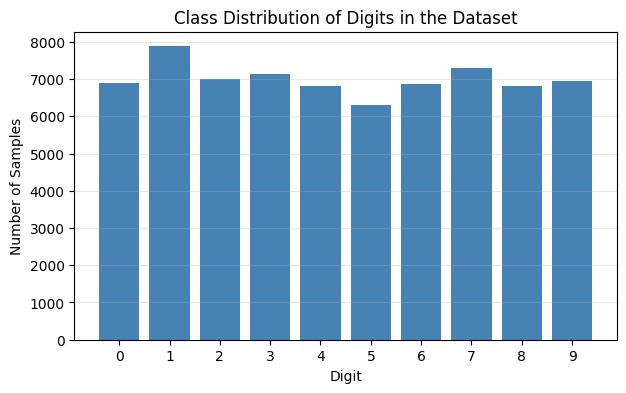

In [8]:
unique, counts = np.unique(all_labels, return_counts=True)

plt.figure(figsize=(7, 4))
plt.bar(unique, counts, color="steelblue")
plt.xlabel("Digit")
plt.ylabel("Number of Samples")
plt.title("Class Distribution of Digits in the Dataset")
plt.xticks(unique)
plt.grid(axis="y", alpha=0.3)
plt.show()

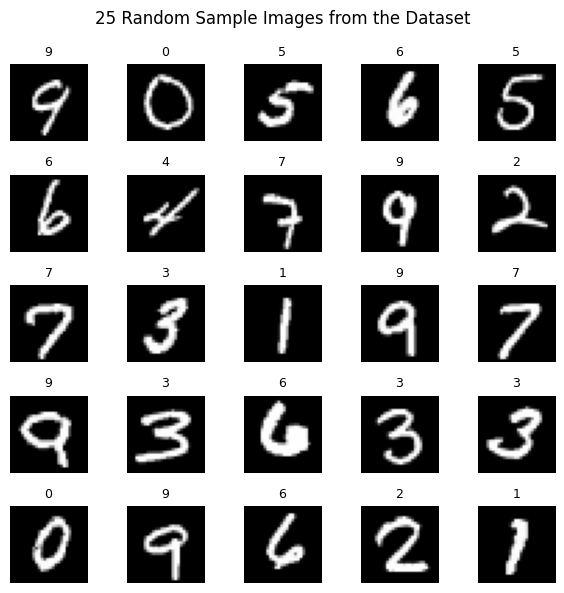

In [9]:
fig, axes = plt.subplots(5, 5, figsize=(6, 6))
rng = np.random.default_rng(SEED)
sample_idxs = rng.choice(len(all_images), size=25, replace=False)

for ax, idx in zip(axes.flatten(), sample_idxs):
    ax.imshow(all_images[idx][0], cmap="gray")
    ax.set_title(str(all_labels[idx]), fontsize=9)
    ax.axis("off")

fig.suptitle("25 Random Sample Images from the Dataset")
plt.tight_layout()
plt.show()

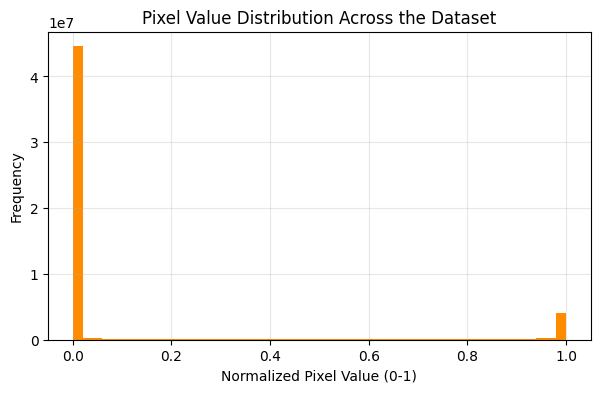

In [10]:
plt.figure(figsize=(7, 4))
plt.hist(all_images.flatten(), bins=50, color="darkorange")
plt.xlabel("Normalized Pixel Value (0-1)")
plt.ylabel("Frequency")
plt.title("Pixel Value Distribution Across the Dataset")
plt.grid(alpha=0.3)
plt.show()

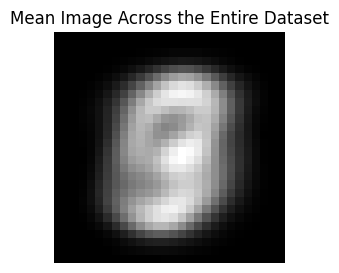

In [11]:
mean_image = all_images.mean(axis=0)[0]

plt.figure(figsize=(3, 3))
plt.imshow(mean_image, cmap="gray")
plt.title("Mean Image Across the Entire Dataset")
plt.axis("off")
plt.show()

In [12]:
class SimpleAutoencoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(True),
            nn.Linear(256, 128),
            nn.ReLU(True),
            nn.Linear(128, latent_dim),
            nn.ReLU(True),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.ReLU(True),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out.view(-1, 1, 28, 28)

    def encode(self, x):
        return self.encoder(x)


simple_ae = SimpleAutoencoder(latent_dim=LATENT_DIM).to(DEVICE)
print(simple_ae)

n_params_simple = sum(p.numel() for p in simple_ae.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters (Simple AE): {n_params_simple:,}")

SimpleAutoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU(inplace=True)
    (5): Linear(in_features=128, out_features=32, bias=True)
    (6): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

Total trainable parameters (Simple AE): 476,720


In [13]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 4, kernel_size=3, stride=1, padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(4, 16, kernel_size=2, stride=2),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

    def encode(self, x):
        return self.encoder(x)


conv_ae = ConvAutoencoder().to(DEVICE)
print(conv_ae)

n_params_conv = sum(p.numel() for p in conv_ae.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters (Conv AE): {n_params_conv:,}")

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
)

Total trainable parameters (Conv AE): 1,077


In [14]:
criterion = nn.MSELoss()

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, name="model"):
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for images, _ in train_loader:
            images = images.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, images)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for images, _ in val_loader:
                images = images.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, images)
                val_running_loss += loss.item() * images.size(0)
        val_loss = val_running_loss / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"[{name}] Epoch {epoch:02d}/{epochs} | "
              f"Train Loss={train_loss:.5f} | Validation Loss={val_loss:.5f}")

    return history

In [15]:

simple_history = train_model(simple_ae, train_loader, val_loader, name="Simple")
conv_history = train_model(conv_ae, train_loader, val_loader, name="Conv")

[Simple] Epoch 01/20 | Train Loss=0.05472 | Validation Loss=0.03222
[Simple] Epoch 02/20 | Train Loss=0.02724 | Validation Loss=0.02438
[Simple] Epoch 03/20 | Train Loss=0.02253 | Validation Loss=0.02161
[Simple] Epoch 04/20 | Train Loss=0.01949 | Validation Loss=0.01852
[Simple] Epoch 05/20 | Train Loss=0.01759 | Validation Loss=0.01692
[Simple] Epoch 06/20 | Train Loss=0.01625 | Validation Loss=0.01596
[Simple] Epoch 07/20 | Train Loss=0.01533 | Validation Loss=0.01519
[Simple] Epoch 08/20 | Train Loss=0.01463 | Validation Loss=0.01450
[Simple] Epoch 09/20 | Train Loss=0.01402 | Validation Loss=0.01413
[Simple] Epoch 10/20 | Train Loss=0.01353 | Validation Loss=0.01361
[Simple] Epoch 11/20 | Train Loss=0.01319 | Validation Loss=0.01340
[Simple] Epoch 12/20 | Train Loss=0.01288 | Validation Loss=0.01311
[Simple] Epoch 13/20 | Train Loss=0.01263 | Validation Loss=0.01300
[Simple] Epoch 14/20 | Train Loss=0.01237 | Validation Loss=0.01268
[Simple] Epoch 15/20 | Train Loss=0.01215 | Vali

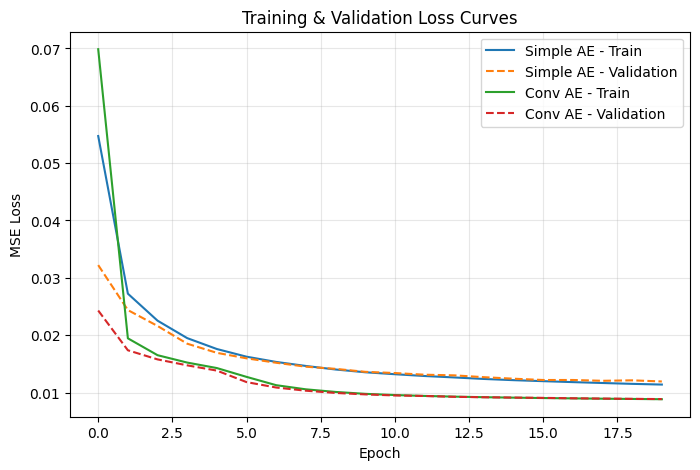

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(simple_history["train_loss"], label="Simple AE - Train")
plt.plot(simple_history["val_loss"], linestyle="--", label="Simple AE - Validation")
plt.plot(conv_history["train_loss"], label="Conv AE - Train")
plt.plot(conv_history["val_loss"], linestyle="--", label="Conv AE - Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training & Validation Loss Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

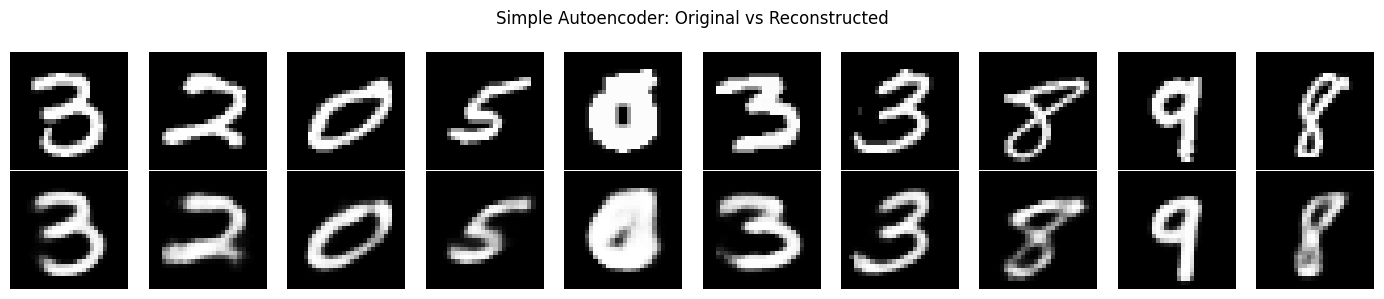

In [17]:
def visualize_reconstructions(model, val_loader, n=10, title="Reconstructions"):
    model.eval()
    images, _ = next(iter(val_loader))
    images = images[:n].to(DEVICE)
    with torch.no_grad():
        recon = model(images)

    images = images.cpu().numpy()
    recon = recon.cpu().numpy()

    fig, axes = plt.subplots(2, n, figsize=(n * 1.4, 3))
    for i in range(n):
        axes[0, i].imshow(images[i][0], cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(recon[i][0], cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("Original", fontsize=10)
    axes[1, 0].set_ylabel("Reconstructed", fontsize=10)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

visualize_reconstructions(simple_ae, val_loader, title="Simple Autoencoder: Original vs Reconstructed")

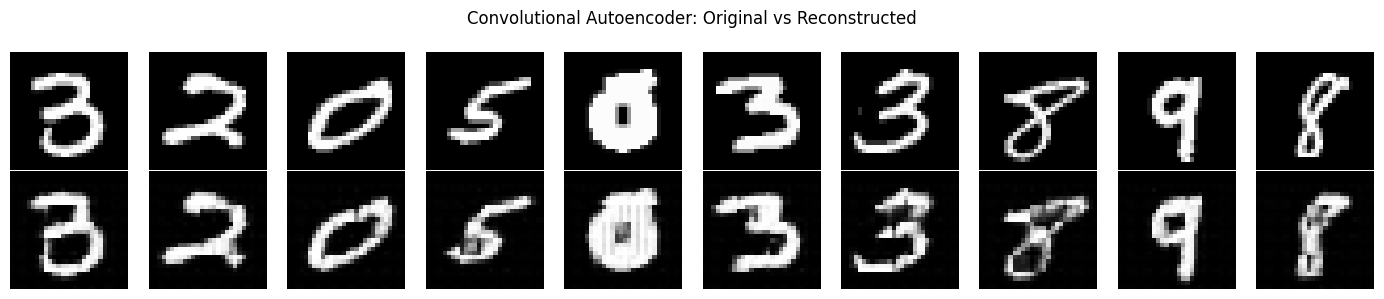

In [18]:
visualize_reconstructions(conv_ae, val_loader, title="Convolutional Autoencoder: Original vs Reconstructed")

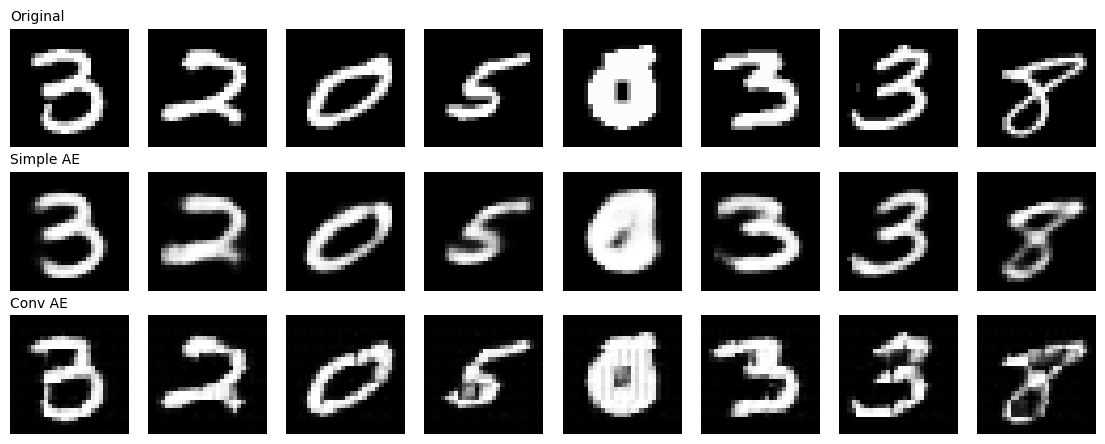

In [19]:
def compare_models(models_dict, val_loader, n=8):
    images, _ = next(iter(val_loader))
    images = images[:n].to(DEVICE)

    recons = {}
    for name, model in models_dict.items():
        model.eval()
        with torch.no_grad():
            recons[name] = model(images).cpu().numpy()

    images_np = images.cpu().numpy()
    n_rows = 1 + len(models_dict)

    fig, axes = plt.subplots(n_rows, n, figsize=(n * 1.4, n_rows * 1.5))

    for i in range(n):
        axes[0, i].imshow(images_np[i][0], cmap="gray")
        axes[0, i].axis("off")
    axes[0, 0].set_title("Original", loc="left", fontsize=10)

    for row, (name, recon) in enumerate(recons.items(), start=1):
        for i in range(n):
            axes[row, i].imshow(recon[i][0], cmap="gray")
            axes[row, i].axis("off")
        axes[row, 0].set_title(name, loc="left", fontsize=10)

    plt.tight_layout()
    plt.show()

compare_models({"Simple AE": simple_ae, "Conv AE": conv_ae}, val_loader)

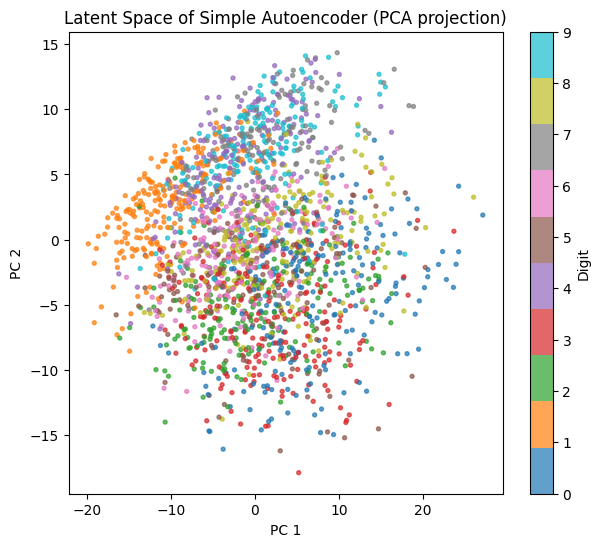

In [20]:
def get_latents(model, loader, max_samples=2000):
    model.eval()
    latents, labels = [], []
    n_collected = 0
    with torch.no_grad():
        for images, lbls in loader:
            images = images.to(DEVICE)
            z = model.encode(images)
            z = z.view(z.size(0), -1)
            latents.append(z.cpu().numpy())
            labels.append(lbls.numpy())
            n_collected += images.size(0)
            if n_collected >= max_samples:
                break
    return np.concatenate(latents)[:max_samples], np.concatenate(labels)[:max_samples]


latents_simple, labels_simple = get_latents(simple_ae, val_loader)

pca = PCA(n_components=2, random_state=SEED)
latents_2d_pca = pca.fit_transform(latents_simple)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(latents_2d_pca[:, 0], latents_2d_pca[:, 1],
                       c=labels_simple, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, label="Digit")
plt.title("Latent Space of Simple Autoencoder (PCA projection)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()

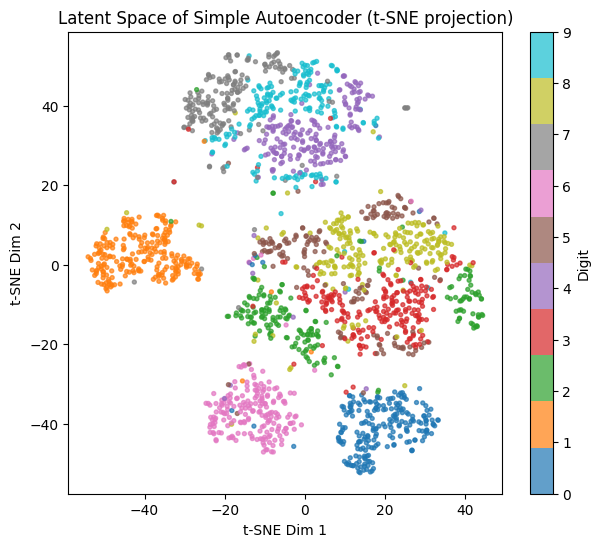

In [21]:
tsne = TSNE(n_components=2, random_state=SEED, init="pca", perplexity=30)
latents_2d_tsne = tsne.fit_transform(latents_simple)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(latents_2d_tsne[:, 0], latents_2d_tsne[:, 1],
                       c=labels_simple, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, label="Digit")
plt.title("Latent Space of Simple Autoencoder (t-SNE projection)")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.show()

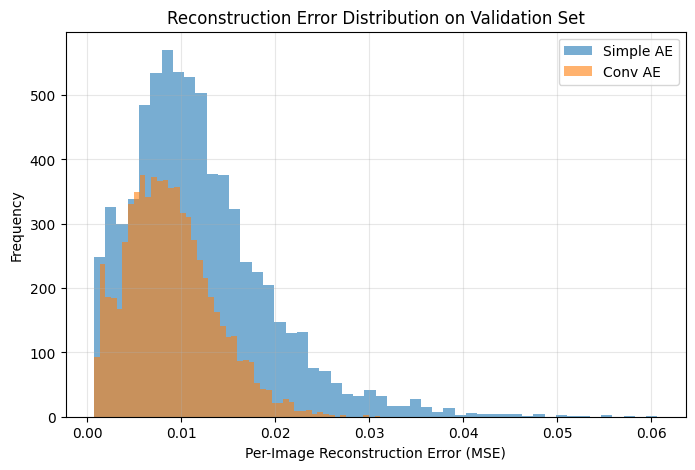

In [22]:
def per_image_mse(model, loader):
    model.eval()
    errors = []
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            err = torch.mean((outputs - images) ** 2, dim=[1, 2, 3])
            errors.append(err.cpu().numpy())
    return np.concatenate(errors)


errors_simple = per_image_mse(simple_ae, val_loader)
errors_conv = per_image_mse(conv_ae, val_loader)

plt.figure(figsize=(8, 5))
plt.hist(errors_simple, bins=50, alpha=0.6, label="Simple AE")
plt.hist(errors_conv, bins=50, alpha=0.6, label="Conv AE")
plt.xlabel("Per-Image Reconstruction Error (MSE)")
plt.ylabel("Frequency")
plt.title("Reconstruction Error Distribution on Validation Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [23]:
results_df = pd.DataFrame({
    "Model": ["Linear (Simple) AE", "Convolutional AE"],
    "Final Train Loss": [simple_history["train_loss"][-1], conv_history["train_loss"][-1]],
    "Final Validation Loss": [simple_history["val_loss"][-1], conv_history["val_loss"][-1]],
    "Trainable Parameters": [n_params_simple, n_params_conv],
})
results_df

,Model,Final Train Loss,Final Validation Loss,Trainable Parameters
0,Linear (Simple) AE,0.011389,0.011928,476720
1,Convolutional AE,0.008833,0.008858,1077
